# A neural-network surrogate inside a nonlinear program

A common pattern in engineering design:

1. sample an expensive model (a CFD run, a flowsheet simulation, an experiment) at a few hundred
   operating points;
2. fit a small neural network to the samples;
3. optimize the operating point with the network standing in for the model.

Step 3 needs the network's exact first and second derivatives if a Newton-type NLP solver is to
converge quickly. For deployment it also needs the network as plain code, without a deep-learning
runtime. Scaly provides both. It also does step 2, because the training loss and its gradient are
ordinary Scaly functions of the weights.

The process here is the consecutive reaction $A \to B \to C$ of the kinetics notebook, run in a
plug-flow reactor. The product is $B$, and $C$ is a by-product whose outlet concentration is
capped. The decision variables are the residence time $\tau$ and the temperature $T$. Per unit of
feed, the margin is the value of the $B$ produced, less the heating and a charge on residence
time (a longer $\tau$ needs a larger reactor):

$$
\max_{\tau, T}\ \ c_B(\tau, T) - \kappa\,(T - T_0) - \mu\,\tau
\quad \text{s.t.}\quad c_C(\tau, T) \le 0.1,\quad 2 \le \tau \le 40\ \text{min},\quad 320 \le T \le 380\ \text{K}.
$$

We pretend that $c_B$ and $c_C$ are only available by simulation. They are learned from samples,
and the NLP is solved on the network.

| Scaly feature | Where |
| --- | --- |
| `sc.vmap` of the network over the samples, weights broadcast | the training loss, with `sc.gradient` for L-BFGS |
| `sc.problem` calling a `Function` with trained weights as constants | the design NLP, exact Hessian for IPOPT |
| `sc.hessian` of the network | curvature checked against differences |
| `write_module` of the network alone | dependency-free C inference |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
from scipy.stats import qmc

import plotstyle
import scaly as sc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "surrogate_optimization"
rng = np.random.default_rng(2)

## The "expensive" model and its samples

The outlet concentrations of an isothermal plug-flow reactor fed with pure $A$ have a closed form.
That makes the true optimum easy to check at the end. The training set is 256 points of a
scrambled Sobol sequence over the design box, with 1% measurement noise.

In [2]:
T_REF, CA0 = 340.0, 1.0
THETA = np.array([np.log(0.08), np.log(0.03), 0.9, 1.1])  # the kinetics notebook's parameters
KAPPA, MU, T0 = 0.002, 0.01, 300.0
TAU_BOX, T_BOX, C_MAX = (2.0, 40.0), (320.0, 380.0), 0.1


def true_model(tau, temp):
  k1, k2 = (np.exp(THETA[i] - 1e4 * THETA[i + 2] * (1 / temp - 1 / T_REF)) for i in (0, 1))
  ca = CA0 * np.exp(-k1 * tau)
  cb = CA0 * k1 / (k2 - k1) * (np.exp(-k1 * tau) - np.exp(-k2 * tau))
  return np.stack([cb, CA0 - ca - cb], axis=-1)


def margin(tau, temp, cb):
  return cb - KAPPA * (temp - T0) - MU * tau


unit = qmc.Sobol(2, seed=4).random_base2(8)
X_TRAIN = np.column_stack([TAU_BOX[0] + unit[:, 0] * np.ptp(TAU_BOX), T_BOX[0] + unit[:, 1] * np.ptp(T_BOX)])
Y_TRAIN = true_model(X_TRAIN[:, 0], X_TRAIN[:, 1]) * (1 + 0.01 * rng.standard_normal((len(X_TRAIN), 2)))
print(
  f"{len(X_TRAIN)} samples; c_B in [{Y_TRAIN[:, 0].min():.2f}, {Y_TRAIN[:, 0].max():.2f}], c_C in [{Y_TRAIN[:, 1].min():.2f}, {Y_TRAIN[:, 1].max():.2f}]"
)

256 samples; c_B in [0.00, 0.58], c_C in [0.00, 1.03]


## The network

A multilayer perceptron with two hidden layers of 24 tanh units. The inputs are scaled to
$[-1, 1]$. The weights are one flat vector, unpacked by slicing, so that the training
gradient is one vector as well.

In [3]:
LAYERS = [2, 24, 24, 2]
SHAPES = [(n_out, n_in) for n_in, n_out in zip(LAYERS[:-1], LAYERS[1:])]
N_WEIGHTS = sum(o * i + o for o, i in SHAPES)
LO, SPAN = np.array([TAU_BOX[0], T_BOX[0]]), np.array([np.ptp(TAU_BOX), np.ptp(T_BOX)])


def mlp(weights, x):
  h, offset = 2.0 * (x - sc.const(LO)) / sc.const(SPAN) - 1.0, 0
  for layer, (n_out, n_in) in enumerate(SHAPES):
    w = weights[offset : offset + n_out * n_in].reshape((n_out, n_in))
    b = weights[offset + n_out * n_in : offset + n_out * n_in + n_out]
    offset += n_out * n_in + n_out
    h = w @ h + b
    if layer < len(SHAPES) - 1:
      h = h.tanh()
  return h


@sc.function(sc.G(sc.L("weights", N_WEIGHTS), sc.L("x", 2), sc.L("y", 2)), sc.L("sq_error", ...))
def sample_loss(inputs):
  weights, x, y = inputs
  return sc.sumsqr(mlp(weights, x) - y).reshape((1,))


@sc.function(sc.L("weights", N_WEIGHTS), sc.G(sc.L("loss", ()), sc.L("grad", ...)))
def training(weights):
  errors = sc.vmap(sample_loss, len(X_TRAIN), [(weights, 0, 0), (sc.const(X_TRAIN.ravel()), 0, 2), (sc.const(Y_TRAIN.ravel()), 0, 2)])
  loss = 0.5 * errors.sum() / len(X_TRAIN) + 1e-6 * sc.sumsqr(weights)
  return loss, sc.gradient(loss, weights)


print(f"{N_WEIGHTS} weights")

722 weights


## Training with L-BFGS

For a network this small, full-batch L-BFGS on the exact gradient is the classic choice. Each
step is one call to the generated `training` function: a `vmap` over the 256 samples forward, then
the same loop in reverse.

In [4]:
def init_weights():
  parts = []
  for n_out, n_in in SHAPES:
    parts += [rng.standard_normal(n_out * n_in) / np.sqrt(n_in), np.zeros(n_out)]
  return np.concatenate(parts)


losses = []
start = time.perf_counter()
fit = optimize.minimize(
  lambda w: training(w),
  init_weights(),
  jac=True,
  method="L-BFGS-B",
  callback=lambda wk: losses.append(float(training(wk)[0])),
  options={"maxiter": 3000, "gtol": 1e-10},
)
WEIGHTS = fit.x
print(f"{fit.nit} L-BFGS iterations in {time.perf_counter() - start:.1f} s, final loss {fit.fun:.2e}")

grid_tau, grid_t = np.meshgrid(np.linspace(*TAU_BOX, 60), np.linspace(*T_BOX, 60))
X_GRID = np.column_stack([grid_tau.ravel(), grid_t.ravel()])
x_s = sc.sym("x", 2)
network = sc.Function._from_exprs("surrogate", [x_s], [mlp(sc.const(WEIGHTS), x_s)], ["x"], ["c"])
pred = np.array([network(x) for x in X_GRID])
truth = true_model(X_GRID[:, 0], X_GRID[:, 1])
print(
  f"surrogate error on a 60 x 60 grid: max {np.abs(pred - truth).max(axis=0).round(4)}, RMS {np.sqrt(np.mean((pred - truth) ** 2, axis=0)).round(4)} (c_B, c_C)"
)

1435 L-BFGS iterations in 5.4 s, final loss 7.94e-05
surrogate error on a 60 x 60 grid: max [0.0687 0.0966], RMS [0.0044 0.0057] (c_B, c_C)


## The design problem on the surrogate

The NLP calls the trained network, whose weights are baked in as constants. IPOPT gets exact
gradients and an exact Lagrangian Hessian, all derived through the tanh layers. The start is the
centre of the box.

In [5]:
@sc.function(sc.L("x", 2), sc.L("c", ...))
def surrogate(x):
  return mlp(sc.const(WEIGHTS), x)


@sc.problem(vars=sc.L("x", 2))
def design(x):
  c = surrogate(x)
  tau, temp = x[0], x[1]
  return sc.ProblemSpec(
    minimize=-(c[0] - KAPPA * (temp - T0) - MU * tau),
    ineq=(sc.bounded(c[1:2], hi=C_MAX, name="byproduct"),),
    lb=sc.const(np.array([TAU_BOX[0], T_BOX[0]])),
    ub=sc.const(np.array([TAU_BOX[1], T_BOX[1]])),
  )


solve = sc.solver(design, "ipopt", name="surrogate_design", options={"tol": 1e-10})
x0 = np.array([np.mean(TAU_BOX), np.mean(T_BOX)])
x_opt, lam_box, _, lam_ineq = solve((x0, np.zeros(2), np.zeros(0), np.zeros(1), ()))
stats = solve.solver_stats()
print(f"IPOPT: {stats.to_solver_status().name} after {stats.iter} iterations; tau = {x_opt[0]:.3f} min, T = {x_opt[1]:.2f} K")
print(f"by-product constraint multiplier {lam_ineq[0]:.3f} ({'active' if abs(lam_ineq[0]) > 1e-6 else 'inactive'})")

IPOPT: OK after 10 iterations; tau = 7.796 min, T = 344.23 K
by-product constraint multiplier 0.791 (active)


### Against the true optimum

The same problem on the true model, solved by SciPy's SLSQP from several starts, gives the
reference. The surrogate's optimum is then evaluated on the true model.

In [6]:
cons = {"type": "ineq", "fun": lambda x: C_MAX - true_model(*x)[1]}
best = min(
  (
    optimize.minimize(
      lambda x: -margin(x[0], x[1], true_model(*x)[0]), start, method="SLSQP", bounds=[TAU_BOX, T_BOX], constraints=[cons], options={"ftol": 1e-14}
    )
    for start in X_TRAIN[::30]
  ),
  key=lambda r: r.fun if r.success else np.inf,
)
x_true = best.x
p_sur_true = margin(*x_opt, true_model(*x_opt)[0])
p_best = margin(*x_true, true_model(*x_true)[0])
print(f"true optimum:       tau = {x_true[0]:.3f} min, T = {x_true[1]:.2f} K, margin {p_best:.5f}")
print(
  f"surrogate optimum:  tau = {x_opt[0]:.3f} min, T = {x_opt[1]:.2f} K, true margin {p_sur_true:.5f} ({100 * (p_best - p_sur_true) / abs(p_best):.2f}% below)"
)
print(f"true by-product at the surrogate optimum: {true_model(*x_opt)[1]:.4f} (limit {C_MAX})")

true optimum:       tau = 6.267 min, T = 346.68 K, margin 0.30999
surrogate optimum:  tau = 7.796 min, T = 344.23 K, true margin 0.30994 (0.01% below)
true by-product at the surrogate optimum: 0.1019 (limit 0.1)


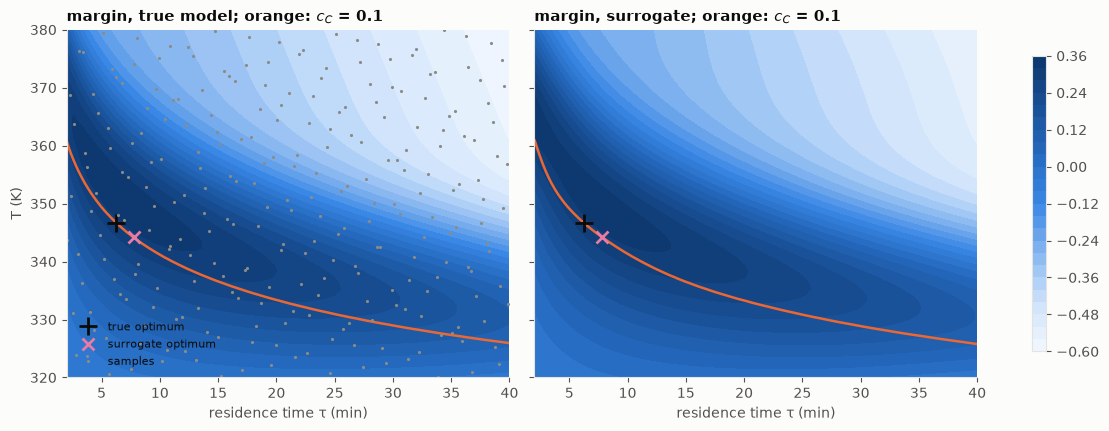

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, cb, cc, title in ((axes[0], truth[:, 0], truth[:, 1], "true model"), (axes[1], pred[:, 0], pred[:, 1], "surrogate")):
  p = margin(X_GRID[:, 0], X_GRID[:, 1], cb).reshape(grid_tau.shape)
  image = ax.contourf(grid_tau, grid_t, p, levels=24, cmap=plotstyle.BLUES)
  ax.contour(grid_tau, grid_t, cc.reshape(grid_tau.shape), levels=[C_MAX], colors=[plotstyle.ORANGE], linewidths=1.8)
  ax.plot(*x_true, "+", color=plotstyle.TEXT, ms=13, mew=2, label="true optimum")
  ax.plot(*x_opt, "x", color=plotstyle.MAGENTA, ms=9, mew=2, label="surrogate optimum")
  ax.set_xlabel("residence time τ (min)")
  ax.set_title(f"margin, {title}; orange: $c_C$ = {C_MAX}")
  ax.grid(False)
axes[0].plot(*X_TRAIN.T, ".", color=plotstyle.NEUTRAL, ms=2.5, label="samples")
axes[0].set_ylabel("T (K)")
axes[0].legend(fontsize=8, loc="lower left")
fig.colorbar(image, ax=axes, shrink=0.85)
plt.show()

## Curvature, exactly

IPOPT's Newton steps use the network's Hessian. `sc.hessian` of the surrogate is checked here
against central differences of `sc.jacobian`.

The comparison above also shows a flat optimum. Along the by-product constraint the margin hardly
changes, so the surrogate's optimum can sit more than a minute away in $\tau$ and still be within
a fraction of a percent in margin. The constraint is a different matter. A small surrogate error
in $c_C$ is a small violation of the true limit, so in practice the limit is backed off, or the
design is checked against the true model and the surrogate refined around it.

In [8]:
jac_fn = sc.jacobian(surrogate, "c", "x")
hess_fn = sc.hessian(sc.Function._from_exprs("cb", [x_s], [surrogate(x_s)[0]], ["x"], ["cb"]), "cb", "x")
hess = hess_fn(x_opt)
eps = np.array([1e-4, 1e-3])
fd = np.column_stack([(jac_fn(x_opt + e) - jac_fn(x_opt - e))[0] / (2 * e[i]) for i, e in enumerate(np.diag(eps))])
print("Hessian of c_B at the optimum (exact):\n", np.array2string(hess, precision=6))
print(f"relative difference to central differences of the Jacobian: {np.abs(hess - 0.5 * (fd + fd.T)).max() / np.abs(hess).max():.1e}")

Hessian of c_B at the optimum (exact):
 [[-0.006981 -0.002051]
 [-0.002051 -0.001589]]
relative difference to central differences of the Jacobian: 2.4e-10


## Inference as plain C

The trained network on its own becomes a small C function. Its weights are static data, and it
is batched over inputs with `vmap`. A controller or a soft sensor can call it without Python or a
deep-learning runtime. Networks trained elsewhere can be read with
`scaly.utils.load_torch_state_dict`, which parses a PyTorch checkpoint without importing torch.

In [9]:
BATCH = 1024


@sc.function(sc.L("X", 2 * BATCH), sc.L("C", ...))
def surrogate_batch(xs):
  return sc.vmap(surrogate, BATCH, [(xs, 0, 2)])


xs = np.column_stack([rng.uniform(*TAU_BOX, BATCH), rng.uniform(*T_BOX, BATCH)])
surrogate_batch(xs.ravel())
start = time.perf_counter()
for _ in range(100):
  out = surrogate_batch(xs.ravel())
per_eval = (time.perf_counter() - start) / 100 / BATCH
print(
  f"batched inference: {1e9 * per_eval:.0f} ns per evaluation; matches the per-point call: {np.abs(out.reshape(BATCH, 2)[:3] - np.array([network(x) for x in xs[:3]])).max():.1e}"
)
module = write_module(surrogate_batch, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB")
module = write_module(solve, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB (the design NLP, linked against IPOPT)")

batched inference: 1527 ns per evaluation; matches the per-point call: 2.2e-16


surrogate_batch.c: 88 lines, 25 kB


surrogate_design.c: 845 lines, 188 kB (the design NLP, linked against IPOPT)
